# Bayesian decoding of neural activity

<div class="alert alert-block alert-info">

### ABOUT THIS LESSON 
---

Lesson time: 60 m   
Contributors: Federico Stella, Davide Spalla

**In this lesson you will learn:**
- What a bayesian decoder is and how to use it
- How to decode the position of an animal running in one and two dimensions
- How to use decoding techniques to investigate neural activity during sleep



## Introduction
---
 
In this lesson we will take a look at some techniques aimed at "reading" neural activity and allowing us to interpret its content and to evaluate how much information it carries about a specific set of stimuli, conditions or states. 



## Naive Bayes decoding
---
 Bayesian decoders are a simple but powerful tool for decoding the value of a stimulus from the observed neural activity.
 Let $P(s)$ denote the probability of presentation of stimulus $s$ (belonging to a set $S$) and $P(r|s)$ denote the conditional probability of obtaining a population response $r$ (out of a response set $R$) when stimulus s is presented. Using Bayes' theorem, we can write the probability of the stimulus given the response:

 $$P(s|r) = \frac{P(r|s)P(s)}{P(r)}$$

This equation gives the posterior probability of a response $r$, given that a stimulus $s$ was presented. 
Bayesian decoding calculates from this posterior probability distribution a single prediction of the most likely stimulus, i.e. the maximum of the posterior distribution. 

In the case of a neural population, $P(r|s)$ lives in an $N$ dimensional space, where $N$ is the number of observed neurons, and its estimation can be a daunting problem. We can, however, make the simplifying assumption that the activity of each neuron is independent.In this case, we can factorize likelihood as:

$$P(r|s)=\prod_{i=1}^{N}P(r_{i}|s)$$

Note that, since we are generally interested in finding the maximum of the posterior distribtuion, we often do not need to evaluate the denominator $P(r)$ (which is usually difficult to calculate).
Moreover, if the prior $P(s)$ is flat (each stimulus value is equiprobable a priori), the problem simplifies further, and we are left with the follwing expression for the decoded stimulus value:

$$s^{*}=argmax_{s}(\prod_{i=1}^{N}P(r_{i}|s))$$

To compute this value, all we need is to estimate the probability of observing a certain response (usually a number of spikes in a given time interval, i.e. the firing rate) given the stimulus, for each of our neurons.
This quantity, estimated throughout the stimulus support, is nothing but the tuning curve of the neuron.
We'll now take a look on how we can use this procedure to decode the position of a running animal from it's place cells, and how we can exploit some mild assumptions on the neural population to make this procedure faster.

### Decoding position on a linear track
---

As an example, let's look at how we can decode the position of the animal on a linear track from the activity of its hippocampal place cells. We will start from simulated data for a clearer example, then move on to some real data.
For the simulated data, well' use some generated with the code you can find in the lesson on [place cells]() of this course.

First, let's import the data:



In [1]:
import pickle
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from scipy.stats import pearsonr
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

In [2]:
#download lesson data
download_data('https://surfdrive.surf.nl/files/index.php/s/TliAW2xObyy0keu')

In [3]:
#code: data import
data_file = 'data/linear_track_data.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

Let's look at the data: we can plot the position as a funtion of time, and superimpose the points in which spikes are emitted by each cell.

In [4]:
def plot_unit(i):
    plt.plot(t, x)
    plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.')
    
interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0))

interactive(children=(IntSlider(value=0, description='i', max=99), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_unit(i)>

<div class="alert alert-block alert-success"> 

### Interactive plotting with ipywidgets

In the cell above the use of [`interact`](https://ipywidgets.readthedocs.io/en/7.6.2/examples/Using%20Interact.html) (from [ipywidgets](https://ipywidgets.readthedocs.io/en/stable/)) to make an interactive plot so that we quickly explore the behavior of all cells. `ipywidgets` offers quite a lot of methods to build simple interactive plots, and can be very useful to explore complex datasets.

As you can see, many cells have place-related activity (their firing concentrates around certain positions in the track). We can use the information provided by the neural population to decode the animals position, with our bayesian decoding framework.  
To perform bayesian decoding, we need to estimate $P(r_{i}|s)$. This is done by computing the firing rate maps of each cell:

In [5]:
# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

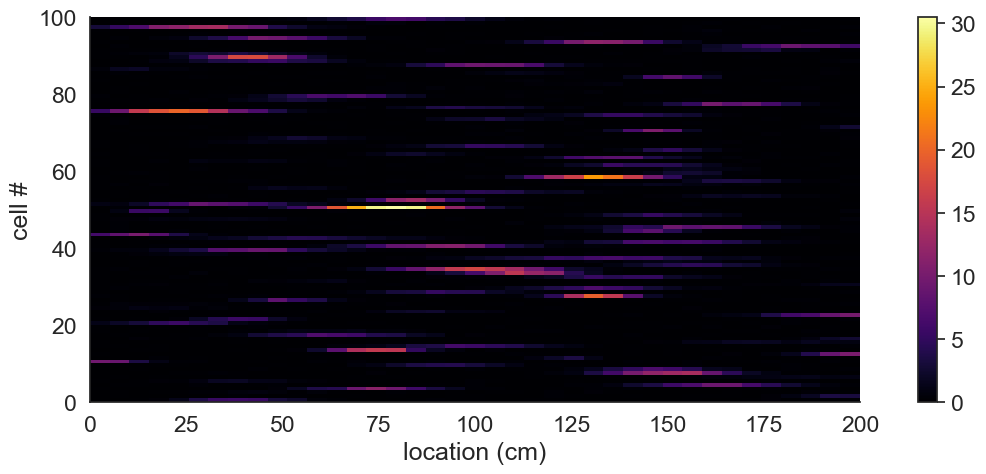

In [6]:
# let's look at the ratemaps
plt.figure(figsize=(15,5))
plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()

Next, we bin the spikes in 33 ms windows (the same temporal resolution of the behaviour). This will give us a snapshot of the neural activity for each position of the animal.

In [7]:
spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

Now we can apply the equations we derived, to decode the position of the animal at each time

In [8]:
# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan   


100%|██████████████████████████████████████████████████████████████████████████████████████| 5026/5026 [00:05<00:00, 910.74it/s]


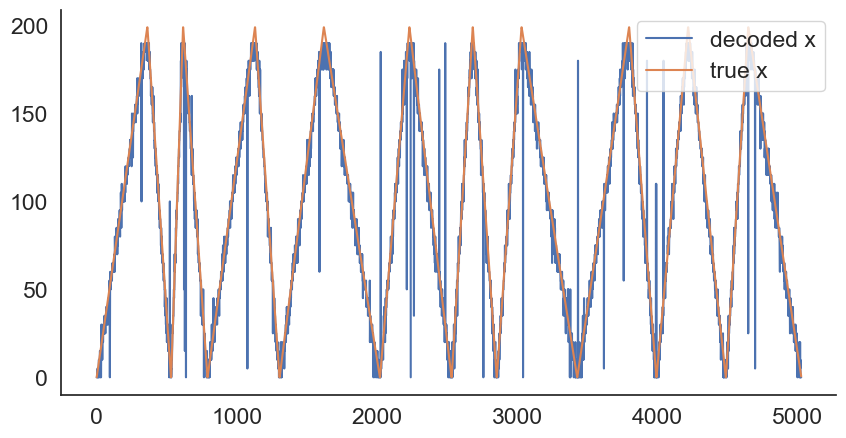

In [9]:
plt.figure(figsize=(10,5))
plt.plot(x_decoded,label= 'decoded x')
plt.plot(true_x,label = 'true x')
plt.legend()

Median error: 3.357155002380459 cm


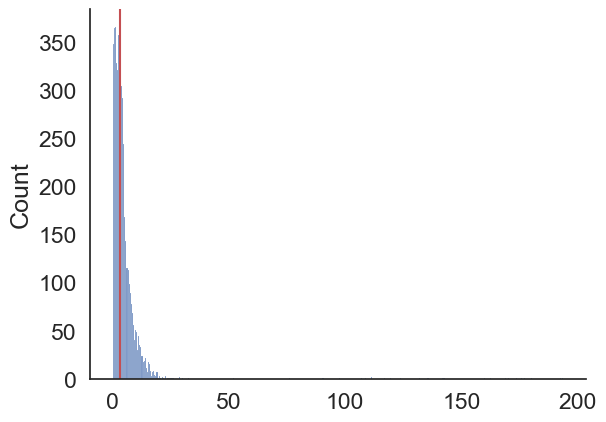

In [10]:
# error distribution
mse = np.sqrt((true_x-x_decoded)**2)
sns.histplot(mse)
plt.axvline(x = np.nanmedian(mse),c='r')
print(f'Median error: {np.nanmedian(mse)} cm')

Our decoder can predict the animal position with a median error around 6 cm. How does this change with sample size, number of cell, and noise? You can explore the effect of these and other features in the [exercises](./exercises.ipynb)

<div class="alert alert-block alert-info">

### Vectorization of the bayes decoder
Above we calculated the (log) posterior distributions by looping both on the time bins and the spatial bins.  
This results in a code that is quite slow, but we can do better: we can leverage the analytical expression of the posterior distirbution, and re-write the code using linear algebra, to obtain a much faster decoder.  

First, since the probability $P(n_{i}|x)$ of observing $n_{i}$ spikes from neuron $i$, given a position x, is assumed to be poissonian, we can write it as:

$$P(n_{i}|x) = \frac{(\tau f_{i}(x))^{n_{i}}}{n_{i}!}exp(-\tau f_{i}(x))$$

Where $f_{i}(x)$ is the average firing rate of the neuron in position $x$ (i.e. the firing rate map value).
For the whole population we then have:

$$P(n|x)=\prod_{i=1}^{N}P(n_{i}|x)= \prod_{i=1}^{N} \frac{(\tau f_{i}(x))^{n_{i}}}{n_{i}!}\exp(-\tau f_{i}(x)) $$

And this gives us the posterior:

$$P(x|n)=CP(x) \prod_{i=1}^{N} \frac{(\tau f_{i}(x))^{n_{i}}}{n_{i}!}\exp(-\tau f_{i}(x)) $$

Where $C$ is a normalization constant (that we do not need to calculate in our maximization procedure) and $P(x)$ is the positional prior.

Taking the logarithm of the posterior, we obtain:

$$\log(P(x|\textbf{n}))= \sum_{i=1}^{N} \left[ n_{i}\log(f_{i}(x)) -\tau f_{i}(x) \right]+\log(\tau) +\log(n!) + C + P(x)$$


We can rewritre the posterior calculation using the matrices `Sp` (n_time_bins x n_space_bins), `Rm` (n_cells,n_space_bins) and `Pr` (1 x n_space_bins):

```
Pt = Sp @ np.log(Rm) - dt*np.sum(Rm, axis=0) + np.log(Pr)
```  

With $dt=1/fps$.



In [11]:
#prior = occupancy / sum(occupancy)
epsilon = pow(1,-10)
log_posteriors = spikes_count @ np.log(firing_rate_maps+epsilon) - (1./fps)*np.sum(firing_rate_maps, axis=0) #+ np.log(prior + epsilon)

x_parallel = [space_bins[np.argmax(P)] for P in log_posteriors]

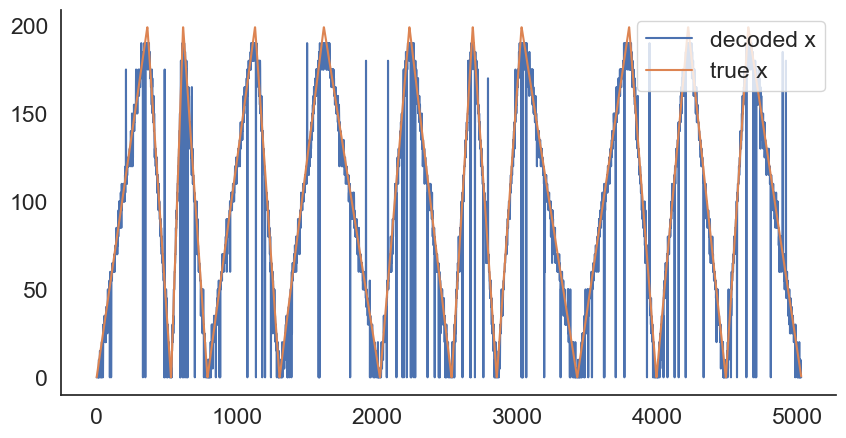

In [12]:
plt.figure(figsize=(10,5))
plt.plot(x_parallel,label= 'decoded x')
plt.plot(true_x,label = 'true x')
plt.legend()

Median error: 3.7851270758785205 cm


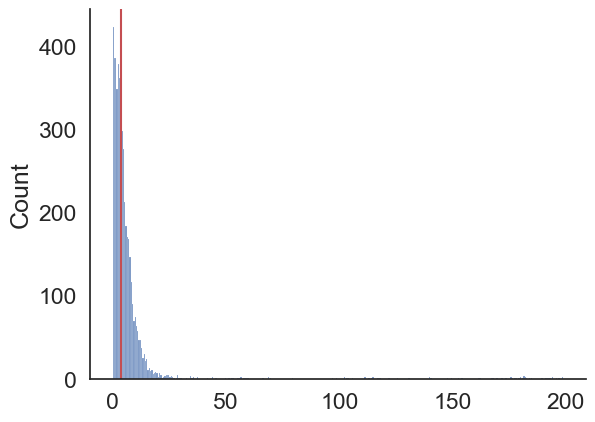

In [13]:
# error distribution
mse = np.sqrt((true_x-x_parallel)**2)
sns.histplot(mse)
plt.axvline(x = np.nanmedian(mse),c='r')
print(f'Median error: {np.nanmedian(mse)} cm')

As you can see, we obtain the same results (with some minor difference due to numerical effects), in a small fraction of the time.

<div class="alert alert-block alert-success"> 

### Timing function exectutions in pyhton
Python offers many tools to benchmark the execution time of your code.
Check out the %timeit [magic command](https://ipython.readthedocs.io/en/stable/interactive/magics.html) for jupyter, or this thread on stack oveflow on [measuring time of funtions](https://stackoverflow.com/questions/5478351/python-time-measure-function)

## Sequential reactivation during sleep
---

The use of decoding methods is not limited to measure the amount of information that a neural population carries about a specific set of stimuli, or to predict what stimulus is present at a given time. It is extremely useful to interpret the content of neural activity when no stimulus is present and such activity is spontaneously generated by the network.

In the case of the hippocampus it has been extensively observed that during rest periods (either while the animal is standing still, waiting somewhere, or while it is sleeping) place cells reactivate specific patterns of activity corresponding to sequences of locations in the environment. This phenomenon, called "replay" is thought to be critical for the formation of memories, for the acquisition of novel knowledge and for the reorganization of different sorts of information in the brain (You can read [this review](https://www.sciencedirect.com/science/article/abs/pii/S0166223610000172?via%3Dihub) for an overview on this field of research).    


Here we want to simulate the occurrence of such reactivation events. Some of them will actually contain sequences, that is, the neural activity will represent a series of locations in the order they appear on the linear track. Other reactivation events will instead contain activity representing locations on the linear track, but these locations will be randomly drawn, so they will have no clear ordering. 

In [14]:
# generate data 

n_events = 200 # number of reactivation events
event_duration = 100 # in bins
sampling_rate = 100 # sampling rate 
t_react = np.arange(0,100)
noise_x_react=5; # Noise in the reactivation of the sequence
noise_t_react=5; # Noise in the timing of the spikes 
noise_firing_rate = 0.1 # the baseline noise firing rate


reactivation_events = np.zeros((n_events,event_duration))
spikes_react = np.zeros((n_events,n_cells,event_duration))

for event in range(n_events):
    if(event<=n_events//2):
    #Generate "real" sequences for the first half of events
        x_start = np.random.uniform(0,track_length) # Starting point
        x_end = np.random.uniform(0,track_length) # Ending point
        x_react = np.linspace(x_start,x_end,event_duration) \
            +np.random.normal(0,noise_x_react,size=event_duration)

    else:
        #Pick locations randomly for the second half 
        x_react = np.random.uniform(0,track_length,size=event_duration);

    x_react[x_react<0]=0;
    x_react[x_react>track_length]=track_length
    
    #store reactivation sequence
    reactivation_events[event,:] = x_react

    
    # Generate spikes according to the location being reactivated in this event
    
    for i in range(n_cells):
        binned_x = np.digitize(x_react,bins=np.linspace(0,track_length,firing_rate_maps.shape[-1]))-1
        inst_rate = firing_rate_maps[i,binned_x] + np.random.normal(0,noise_firing_rate,size=len(binned_x))
        inst_rate[inst_rate<0] = 0
        spikes_loc = np.where(np.random.poisson(inst_rate/sampling_rate)>0)
        spikes_loc = spikes_loc + np.round(np.random.normal(0,noise_t_react,size=len(spikes_loc)))
        spikes_loc = spikes_loc[np.logical_and(spikes_loc>0,spikes_loc<event_duration)]
        spikes_react[event,i,spikes_loc.astype(int)] = 1
        
    


To visualize the sequence, we will plot the activity after sorting the cells according to the place field center (in this case defined as the peak location of their firing rate map).

Text(0, 0.5, 'cell #')

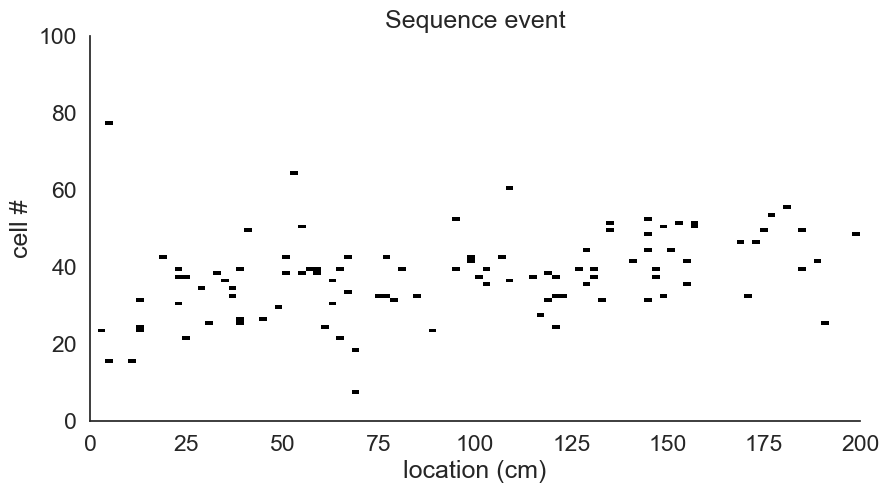

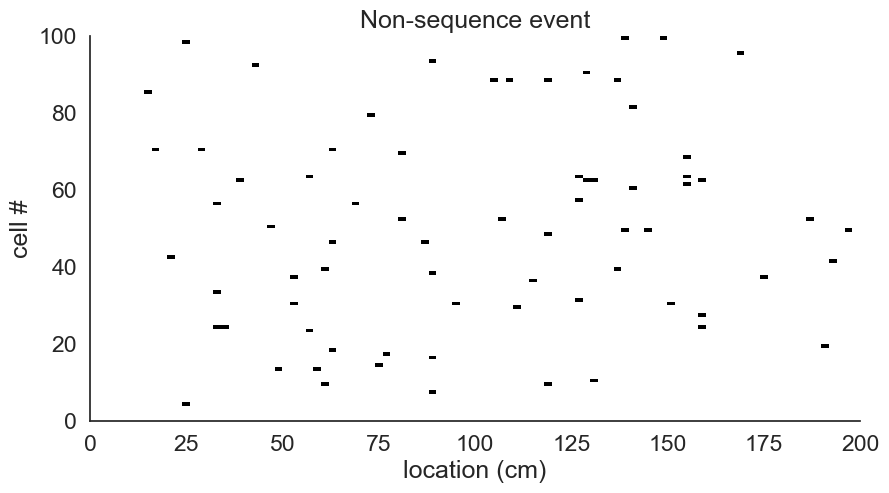

In [15]:
pfc_idxs = [np.argmax(rate_map) for rate_map in firing_rate_maps] 
sorted_idxs = np.argsort(pfc_idxs)


event = 50
plt.figure(figsize=(10,5))
plt.title('Sequence event')
plt.imshow(spikes_react[event,sorted_idxs,:], cmap='Greys', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')

event = 150
plt.figure(figsize=(10,5))
plt.title('Non-sequence event')
plt.imshow(spikes_react[event,sorted_idxs,:], cmap='Greys', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')


We can now use bayesian decoding to detect reactivated sequences among these events.
To do so, we fit a straight line to the decoded locations, taken in order of observation time. The slope of the line will around zero for random reactivations, that do not progress during time, but it will be positive (or negative) for sequences in which the decoded location increases (or decreases) in time on average.

In [16]:
time_window = 10 # number of bins to aggregate during decoding

reactivation_slope = np.zeros(n_events)

for event in range(n_events):

    event_spikes = spikes_react[event]
    # First we bin the events in windows of 10 bins
    spikes_sampled = np.zeros((n_cells,event_spikes.shape[1]//time_window))
    # We generate a new spike matrix with the re-sized window
    for t_r in range(1,event_spikes.shape[1]//time_window):
        spikes_sampled[:,t_r] = np.sum(event_spikes[:,(t_r-1)*time_window :(t_r)*time_window],axis=1)

In [27]:
# to do: bayesian decoding
t_resize = 10 # We use spikes from multiple time windows for the decoding

reactivation_slopes = np.zeros(n_events)
reactivation_pvalues = np.zeros(n_events)

for event in range(n_events):

    event_spikes = spikes_react[event]
    spikes_sampled = np.zeros((n_cells,event_spikes.shape[1]//t_resize))

    # We generate a new spike matrix with the re-sized window
    for t_r in range(1,event_spikes.shape[1]//t_resize):
        spikes_sampled[:,t_r] = np.sum(event_spikes[:,(t_r-1)*t_resize :(t_r)*t_resize],axis=1)


    # We then perform decoding on the aggregated spikes
    x_decoded = np.zeros(spikes_sampled.shape[1])

    for t_bin in range(spikes_sampled.shape[1]):

        if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes

            posterior = np.empty(firing_rate_maps.shape[-1])
            for i in range(len(posterior)):
                posterior[i] = sum(poisson.logpmf(spikes_sampled[:,t_bin],firing_rate_maps[:,i]*t_resize/fps)+pow(1,-15))

            x_decoded[t_bin] = space_bins[np.argmax(posterior)]

        else:
            x_decoded[t_bin] = np.nan   

        # We fit a line to the decoded positions, and save the slope
        slope,_ = np.polyfit(np.arange(len(x_decoded)),x_decoded,deg=1)
        reactivation_slopes[event] = slope
        # And calculate the pvalue of the pearson correlation
        corr = pearsonr(np.arange(len(x_decoded)),x_decoded)
        reactivation_pvalues[event] = corr[1]


/var/folders/6z/lrk02sv52pn2vqxpttkyq1m00000gn/T/ipykernel_25663/1835679459.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(np.arange(len(x_decoded)),x_decoded)


Here we plot the distribution of slopes and correlation pvalues for the events in our dataset.

<Axes: ylabel='Count'>

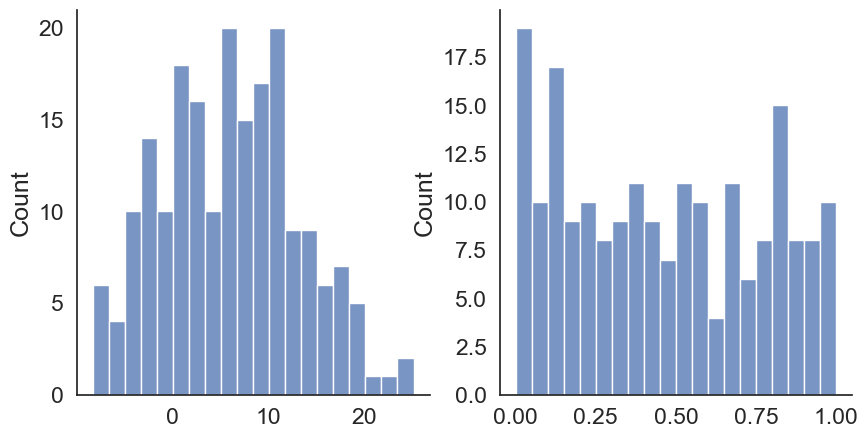

In [28]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(reactivation_slopes,bins=20)
plt.subplot(1,2,2)
sns.histplot(reactivation_pvalues,bins=20)


With this method we can detect a forward or backward sequence in our reactivation events. The calculation of the correlation p-value also allows us to assign a statistical confidence on how strongly the activity was sequentially organized.  



<div class="alert alert-block alert-info">

### Key points 

- Naive Bayes decoders use bayes' formula to estimate the probability of observing a stimulus given a certain pattern of neural responses
- In its simplest form, this algorithms relies on the assumption of *flat stimulus prior*, *and independence between neurons*
- This decoder can be used to recover the animal position during 1D and 2D navigation
- Decoding approaches can be used to investigate spontaneous neural activity during sleep or rest.

<div class="alert alert-block alert-info">

### References and resources

**Books & papers**
* Review on neural decoding: https://www.nature.com/articles/nrn2578
* Review on information processing in neural populations: https://www.nature.com/articles/35039062 
* Review on hippocampal replay and reactivation: https://www.sciencedirect.com/science/article/abs/pii/S0166223610000172?via%3Dihub 

**Websites & blogposts**

**Software**
* A python package for neural decoding: https://github.com/KordingLab/Neural_Decoding



# Exercises

## Exercise 1
---

You can find below the code that was used to generate the activity of place cells on a linear track.
Use the code and the decoding procedure you lerned about in the lesson to explore how different features of the data impact our ability to decode position.
In particular:

A - Try to use different fractions of our data samples. How does the median error change when the the number of available sample gets larger? You do not need to re-generate any data, just randomly sub-sample the data to different fractions.

B - How many place cells do we need to reliably decode position? Try to re-do the decoding using only 10 cell, then 20, and so on. How does the median error change? Does it reach an asymptote? (Also in this case, you do not need to re-generate the data, you can just select a random subset of cells each time)

C - Generate new data using the code below, changing the firing rate noise (changing the value of the variable `noise firing_rate`). How does this noise impact the decoding?

In [ ]:
# Reusable flat-prior Poisson Bayes decoder + rate-map estimator (the lesson's vectorized form)
dt   = 1. / fps
n_sb = len(space_bins) - 1

def estimate_ratemaps(sp_count, pos):
    """Firing-rate maps (n_cells x n_sb) from binned counts and matching positions."""
    idx = np.clip(np.digitize(pos, space_bins) - 1, 0, n_sb - 1)
    rm = np.zeros((sp_count.shape[1], n_sb))
    for b in range(n_sb):
        m = idx == b
        if m.any():
            rm[:, b] = sp_count[m].mean(0) / dt          # mean count per bin -> rate (Hz)
    return rm

def decode(sp_count, rm, eps=1e-10):
    logP = sp_count @ np.log(rm + eps) - dt * rm.sum(0)  # flat prior; constant log(n!) dropped
    return space_bins[np.argmax(logP, axis=1)]

def median_error(sp_count, pos, rm):
    return np.nanmedian(np.abs(pos - decode(sp_count, rm)))

rng    = np.random.default_rng(0)
n_time = spikes_count.shape[0]

# A - vary the number of samples used to ESTIMATE the maps, then decode the whole session
fractions = np.array([0.02, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0])
err_frac = [median_error(spikes_count, true_x,
                         estimate_ratemaps(spikes_count[s], true_x[s]))
            for f in fractions
            for s in [rng.choice(n_time, max(int(f*n_time), 1), replace=False)]]

# B - vary the number of cells (subset rows of the full, well-estimated maps)
cell_counts = [5, 10, 20, 40, 60, 80, n_cells]
err_cells = [median_error(spikes_count[:, sel], true_x, firing_rate_maps[sel])
             for nc in cell_counts
             for sel in [rng.choice(n_cells, nc, replace=False)]]

# C - vary the firing-rate noise: re-simulate spikes using the lesson maps as ground truth
bin_idx = np.clip(np.digitize(true_x, space_bins) - 1, 0, n_sb - 1)
gt = firing_rate_maps[:, bin_idx]                        # ground-truth rate per frame (Hz)
noise_levels = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
err_noise = [median_error(sp, true_x, estimate_ratemaps(sp, true_x))
             for nf in noise_levels
             for sp in [rng.poisson((gt + nf) * dt).T]]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot((fractions * n_time).astype(int), err_frac, 'o-'); ax[0].set_xlabel('# samples for rate maps'); ax[0].set_xscale('log')
ax[1].plot(cell_counts, err_cells, 'o-');                     ax[1].set_xlabel('# cells')
ax[2].plot(noise_levels, err_noise, 'o-');                    ax[2].set_xlabel('noise firing rate (Hz)')
ax[0].set_ylabel('median error (cm)')
for a in ax:
    sns.despine(ax=a)
plt.tight_layout()

**Expected behaviour (we reason about the trends rather than read the figures).**

- **A — sample size.** The tuning curves are histogram estimators: with few samples some spatial bins are barely visited, so their rate is noisy or undefined and the likelihood there is uninformative. Median error should be large for small fractions and fall steeply, then **plateau** once every bin is sampled enough that more data no longer sharpens the maps — the usual $\propto 1/\sqrt{\text{counts per bin}}$ saturation of a rate-map estimate.

- **B — number of cells.** Independent place cells each add a term to the log-posterior, so positional information accumulates roughly linearly while their fields tile the track. Error should **drop quickly over the first few tens of cells and approach an asymptote** set by the 5 cm bin width and the residual Poisson noise; beyond ~40–60 cells extra neurons mostly duplicate coverage. (Here we subset the *already well-estimated* maps, so this isolates the population-size effect from map-estimation noise.)

- **C — firing-rate noise.** A flat background rate injects position-independent spikes, lowering the SNR of every tuning curve. Median error should **rise with noise**, but more gently than one might expect: because the added rate is *spatially uniform*, it is largely absorbed when the maps are re-estimated — it shifts every bin by roughly the same amount, so the $-\tau\sum_i f_i(x)$ occupancy term is nearly constant in $x$ and cancels in the `argmax`; only the log-compression of tuning contrast and the extra Poisson variance actually hurt. Substantial degradation toward chance therefore requires a noise rate well *above* the peak signal rate (~5 Hz), not merely comparable to it. A spatially *structured* noise would be far more damaging.

## Exercise 2
---
In the loop implementation of the decoder, we used `poisson.logpmf(k,mu)` to calculate the log probability of observing $k$ spikes given an average firing rate of $\mu$. 
This is mathematically equivalent to `np.log(poisson.pmf(k,mu))`, in which we calculate the probability, and then take the log.


Re-run the decoding substituting this expression:

```
posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
```

To the line we are using to calculate the posterior.
Do you see any difference in the results? What do you think this is due to?

In [ ]:
# Exercise 2 - poisson.logpmf  vs  np.log(poisson.pmf): numerical stability
from scipy.stats import poisson

mu = firing_rate_maps / fps                      # expected counts per bin  (n_cells x n_space_bins)

def decode_loop(use_pmf, eps):
    xd = np.full(spikes_count.shape[0], np.nan)
    for tb in range(spikes_count.shape[0]):
        if spikes_count[tb].sum() > 0:
            if use_pmf:
                post = [np.sum(np.log(poisson.pmf(spikes_count[tb], mu[:, i]) + eps)) for i in range(mu.shape[1])]
            else:
                post = [np.sum(poisson.logpmf(spikes_count[tb], mu[:, i])) for i in range(mu.shape[1])]
            xd[tb] = space_bins[np.argmax(post)]
    return xd

x_logpmf  = decode_loop(use_pmf=False, eps=0.0)
x_pmf_eps = decode_loop(use_pmf=True,  eps=1e-15)     # the floor done *correctly*
print(f'median error  logpmf        : {np.nanmedian(np.abs(true_x - x_logpmf)):.2f} cm')
print(f'median error  log(pmf+1e-15): {np.nanmedian(np.abs(true_x - x_pmf_eps)):.2f} cm')
print(f'identical decode in {100*np.nanmean(x_logpmf == x_pmf_eps):.1f}% of spiking bins')

# the exercise literally writes pow(1,-15), which is NOT 1e-15:
print(f'\npow(1,-15)  = {pow(1,-15)}   <- adds a flooring constant of 1.0, larger than any pmf')
print(f'pow(10,-15) = {pow(10,-15):.0e}')
# demonstrate the collapse on one busy bin without re-running the whole loop:
tb = int(np.argmax(spikes_count.sum(1)))
flat = np.array([np.sum(np.log(poisson.pmf(spikes_count[tb], mu[:, i]) + pow(1, -15))) for i in range(mu.shape[1])])
print(f'with +pow(1,-15) the posterior over space spans only {flat.max()-flat.min():.1e} in log-prob (≈ flat -> argmax meaningless)')

**What happens and why.**

`poisson.logpmf(k, μ)` evaluates $k\log\mu - \mu - \log(k!)$ directly, computing $\log(k!)$ through `gammaln`. It stays finite even when the probability itself is astronomically small. `np.log(poisson.pmf(k, μ))` instead forms the probability *first*, and for a population of ~100 neurons the joint likelihood routinely **underflows to `0.0`** in double precision (any value below ≈ $10^{-308}$). Then `log(0) = -inf` poisons the sum and the `argmax` becomes undefined, which is why an `eps` floor is bolted on.

With the *correct* floor `1e-15` the two decoders agree on the large majority of spiking bins — they are mathematically identical and diverge only where the pmf underflows; there the floored version has thrown away the gradient of the likelihood, so its median error is equal or slightly worse.

The bigger trap is in the expression the exercise asks you to substitute: it writes **`pow(1,-15)`**, which is $1^{-15} = 1.0$, **not** $10^{-15}$. Adding `1.0` to a probability $\le 1$ makes every term `≈ log(1) ≈ 0`: the posterior goes flat, all positional information is erased, and the decoder collapses to a constant guess (median error of order a third of the track). The lesson gets away with the same typo only because it adds the constant to `logpmf`, where $10^{-15}$ — or even $1.0$ — is negligible next to a log-likelihood.

**Takeaways:** always accumulate likelihoods in log-space with `logpmf`; and the *magnitude* of a regularising epsilon matters as much as its presence — `pow(1,-15)` and `pow(10,-15)` differ by fifteen orders of magnitude.

## Exercise 3
---
A - Estimate the quality of the sequence detection methods we saw in the lesson. How many false poistive does it find? How many false negatives?

B - Investigate the effect of `noise_x_react` and `noise_t_react` on the false positive rate and the false negative rate of our detection procedure.

C - What kind of sequence can our methods detect? What kind of activity, despide being sequential, could escape our detection method? Would you have an idea for a different method for sequence detection?

In [ ]:
# Exercise 3A - confusion matrix of the lesson's detector (Pearson p-value < 0.05)
# Ground truth from the generator: events 0..n_events//2 are real sequences, the rest random.
is_seq   = np.arange(n_events) <= n_events // 2
detected = reactivation_pvalues < 0.05

TP = np.sum(detected &  is_seq);  FN = np.sum(~detected &  is_seq)
FP = np.sum(detected & ~is_seq);  TN = np.sum(~detected & ~is_seq)
print(f'TP={TP}  FN={FN}  FP={FP}  TN={TN}')
print(f'false-positive rate = {FP/(FP+TN):.2f}   false-negative rate = {FN/(FN+TP):.2f}')


# Exercise 3B - re-simulate reactivations at several noise levels and re-measure FPR / FNR
n_full  = firing_rate_maps.shape[-1]
pf_bins = np.linspace(0, track_length, n_full)

def simulate_reactivations(noise_x, noise_t, n_events=200, dur=100, srate=100, noise_fr=0.1, seed=0):
    rng = np.random.default_rng(seed)
    S = np.zeros((n_events, n_cells, dur))
    for ev in range(n_events):
        if ev <= n_events // 2:                                   # real linear sequence
            x0, x1 = rng.uniform(0, track_length, 2)
            xr = np.linspace(x0, x1, dur) + rng.normal(0, noise_x, dur)
        else:                                                      # random (non-sequence)
            xr = rng.uniform(0, track_length, dur)
        bx = np.clip(np.digitize(np.clip(xr, 0, track_length), pf_bins) - 1, 0, n_full - 1)
        for i in range(n_cells):
            rate = np.clip(firing_rate_maps[i, bx] + rng.normal(0, noise_fr, dur), 0, None)
            loc  = np.where(rng.poisson(rate / srate) > 0)[0]
            loc  = loc + np.round(rng.normal(0, noise_t, size=loc.shape))
            loc  = loc[(loc > 0) & (loc < dur)].astype(int)
            S[ev, i, loc] = 1
    return S

def detect_pvalues(S, t_resize=10, eps=1e-10):
    pv = np.ones(S.shape[0])
    for ev in range(S.shape[0]):
        nb = S.shape[2] // t_resize
        ss = np.array([S[ev, :, (k-1)*t_resize:k*t_resize].sum(1) for k in range(1, nb)])  # (windows x cells)
        keep = ss.sum(1) > 0
        if keep.sum() < 3:
            continue
        logP = ss[keep] @ np.log(firing_rate_maps + eps) - (t_resize/fps)*firing_rate_maps.sum(0)
        xd = space_bins[np.argmax(logP, axis=1)]
        if np.std(xd) > 0:
            pv[ev] = pearsonr(np.arange(len(xd)), xd)[1]
    return pv

def fpr_fnr(pv):
    seq = np.arange(len(pv)) <= len(pv) // 2
    det = pv < 0.05
    return np.sum(det & ~seq)/np.sum(~seq), np.sum(~det & seq)/np.sum(seq)

print('\n        noise_x sweep            noise_t sweep')
print('  val    FPR    FNR        val    FPR    FNR')
for v in [0, 2, 5, 10, 20]:
    fx = fpr_fnr(detect_pvalues(simulate_reactivations(v, 5)))
    ft = fpr_fnr(detect_pvalues(simulate_reactivations(5, v)))
    print(f'  {v:3d}   {fx[0]:.2f}   {fx[1]:.2f}        {v:3d}   {ft[0]:.2f}   {ft[1]:.2f}')

**Discussion (we reason about the expected outcome rather than read the figures).**

**A — detector quality.** The rule "flag an event if the Pearson *p*-value of decoded-position vs. time is `< 0.05`" is a parametric significance test on a straight-line fit. For the random events the decoded positions are unordered, so the *p*-value is approximately uniform on $[0,1]$ — by construction roughly **5% of them cross the 0.05 threshold and become false positives**. For the real sequences the false-negative count is set entirely by how much `noise_x_react`/`noise_t_react` blur the trajectory: at the lesson's settings (both = 5) most sequences still fit a line well, so FN should be modest but non-zero.

**B — effect of the two noises.**
- `noise_x_react` jitters the *represented position* around the ideal ramp. Increasing it lowers the linear correlation of true sequences → **FNR rises monotonically**, approaching 1 once the jitter is comparable to the track length (sequences become indistinguishable from random). The FPR is unaffected — it stays pinned near the 0.05 set by the test itself.
- `noise_t_react` jitters *spike timing*, smearing spikes across decoding windows. This also degrades the monotonic order and **raises FNR**, though typically more gently than spatial noise because the 10-bin aggregation windows already average over some of it. Again FPR stays ≈ 0.05.

**C — what the method can and cannot detect.** Fitting a single straight line (equivalently, a Pearson correlation) detects **monotonic, roughly constant-velocity trajectories** — forward or backward linear sweeps across the track. It is blind to any ordered activity that is not globally linear:
- out-and-back or oscillating trajectories (the net slope ≈ 0, so they look random),
- piecewise or curved trajectories, and trajectories that revisit locations,
- sequences confined to a short stretch of track (little dynamic range → weak correlation),
- sequences compressed below the window resolution, or stationary reactivation of a single place.

Better detectors relax the straight-line assumption: **rank-order (Spearman) correlation** of cell firing order, **weighted correlation / line-fitting via the Radon transform** on the full posterior (the standard replay score), or **state-space / HMM decoders with a continuity prior** that score trajectory likelihood under an explicit movement model. Crucially, significance should be assessed against **shuffled surrogates** (e.g. circularly shifting each cell's spikes, or permuting place-field identities) rather than a parametric *p*-value, since the latter assumes independent, normally distributed residuals that decoded positions do not satisfy.

### Code for data generation
---
This is the place-cell simulator used to produce `linear_track_data.pickle`. Run it (optionally changing `noise_firing_rate`, `n_cells`, …) to create fresh data for Exercise 1C, then re-run the lesson's import/decoding cells on the new pickle.

In [ ]:
import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 5]
from ipywidgets import interact
import ipywidgets as widgets


track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution

bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

In [ ]:
# GENERATE TRAJECTORY
n_runs = 10
use_stops = False
av_running_speed = 10 # the average running speed (in cm/s)
fps = 10 # the number of "video frames" per second
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs)

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])
for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    if use_stops:
        x = np.concatenate((x, stop1, run1, stop2, run2))
    else:
        x = np.concatenate((x, run1, run2))
t = np.arange(len(x))/fps

# GENERATE SPIKES
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []
for i in range(n_cells):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

In [ ]:
import pickle

file_name = 'linear_track_data.pickle' # change this name when you save new data

out_data = {}
out_data['x'] = x
out_data['t'] = t
out_data['spikes'] = spikes
out_data['track_length'] = track_length
out_data['fps'] = fps

with open('data/'+file_name,'wb') as f:
    pickle.dump(out_data,f)